# Lab 01 – Hồi quy tuyến tính: 6 bài tập

Notebook gồm 6 bài tập mở rộng dựa trên mô hình hồi quy đã xây dựng ở phần "7 bước cơ bản" (lọc dữ liệu, biểu đồ, đổi biến, thêm biến, tốc độ học, hàm dự đoán có cảnh báo ngoại suy).

In [1]:
from pathlib import Path
import os
import pandas as pd

for thu_muc in (Path.cwd(), Path.cwd().parent):
    if (thu_muc / "data" / "gia_nha.csv").is_file():
        os.chdir(thu_muc)
        break
else:
    raise FileNotFoundError("Khong tim thay data/gia_nha.csv")

_doc_csv_goc = pd.read_csv

def _doc_csv(duong_dan, *args, **kwargs):
    if duong_dan == "gia_nha.csv":
        duong_dan = Path("data") / duong_dan
    return _doc_csv_goc(duong_dan, *args, **kwargs)

pd.read_csv = _doc_csv


**Bài tập 1: Lọc ra nhóm căn hộ lớn**


In [2]:
#-*- coding: utf-8 -*-
"""Bài tập 1: Lọc ra nhóm căn hộ lớn có diện tích > 100 m2."""

import pandas as pd
df = pd.read_csv("gia_nha.csv")
nhom_lon = df[df["dien_tich"] > 100]

print("So can ho co dien tich lon hon 100 m2:", len(nhom_lon))

print("Gia trung binh cua nhom nay          :", round(nhom_lon["gia"].mean(), 2), "ty dong")


So can ho co dien tich lon hon 100 m2: 10
Gia trung binh cua nhom nay          : 8.96 ty dong


**Bài tập 2: Vẽ biểu đồ phân tán theo số phòng**

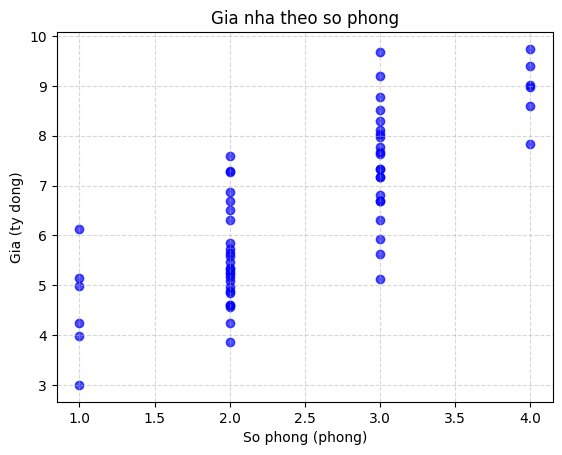

--- NHAN XET BAI TAP 2 ---
Nhan xet: Gia nha co xu huong tang khi so phong ngu tang lên. Tuy nhien, voi cung mot so phong, gia nha van co su dao dong lon do phu thuoc vao dien tich va tuoi nha.


In [3]:
# -*- coding: utf-8 -*-
"""Bài tập 2: Vẽ biểu đồ phân tán theo số phòng."""

import matplotlib.pyplot as plt
import pandas as pd

# 1. Đọc dữ liệu
df = pd.read_csv("gia_nha.csv")

# 2. Vẽ biểu đồ phân tán giữa số phòng và giá
plt.scatter(df["so_phong"], df["gia"], alpha=0.7, color="blue")
plt.xlabel("So phong (phong)")
plt.ylabel("Gia (ty dong)")
plt.title("Gia nha theo so phong")
plt.grid(True, linestyle="--", alpha=0.5)

# 3. Lưu hình trước khi hiển thị (lưu vào cùng thư mục chạy)
plt.savefig("bai2.png", dpi=150)
plt.show()

# 4. Câu nhận xét về xu hướng
print("--- NHAN XET BAI TAP 2 ---")
print(
    "Nhan xet: Gia nha co xu huong tang khi so phong ngu tang lên. "
    "Tuy nhien, voi cung mot so phong, gia nha van co su dao dong lon do phu thuoc vao dien tich va tuoi nha."
)

**Bài tập 3: Đổi biến đầu vào sang tuổi nhà**

In [4]:
# -*- coding: utf-8 -*-
"""Bài tập 3: Đổi biến đầu vào sang tuổi nhà (dùng công thức bình phương tối thiểu)."""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Đọc dữ liệu từ file CSV
df = pd.read_csv("gia_nha.csv")

# 2. Đổi biến đầu vào sang tuoi_nha, biến mục tiêu vẫn là gia
x = df["tuoi_nha"].to_numpy()
y = df["gia"].to_numpy()

# 3. Tính giá trị trung bình
x_tb = x.mean()
y_tb = y.mean()

# 4. Công thức bình phương tối thiểu
tu_so = ((x - x_tb) * (y - y_tb)).sum()
mau_so = ((x - x_tb) ** 2).sum()

w = tu_so / mau_so
b = y_tb - w * x_tb

# 5. In kết quả hệ số w và b với 6 chữ số sau dấu phẩy
print("--- KET QUA BAI TAP 3 ---")
print(f"He so goc  w = {w:.6f}")
print(f"He so chan b = {b:.6f}")
print()
print(f"Mo hinh: gia = {w:.6f} * tuoi_nha + {b:.6f}")
print()

# 6. Câu nhận xét và giải thích dấu âm của w
print("--- NHAN XET VA GIAI THICH DAU CUA W ---")
print(f"Nhan xet: He so goc w mang dau AM (w = {w:.6f}).")
print(
    "Giai thich: w la muc thay doi cua gia khi tuoi nha tang thêm 1 nam. "
    "Dau am noi len quan he nghich bien giua tuoi nha va gia ban: "
    f"nha cang cu (tuoi nha tang), gia trị hao mon va khau hao cang lon "
    f"khien gia ban giam xuong (trung binh moi nam tuoi nha tang thêm khien gia giam khoảng {abs(w)*1000:.1f} trieu dong)."
)
print()



--- KET QUA BAI TAP 3 ---
He so goc  w = -0.037858
He so chan b = 6.983593

Mo hinh: gia = -0.037858 * tuoi_nha + 6.983593

--- NHAN XET VA GIAI THICH DAU CUA W ---
Nhan xet: He so goc w mang dau AM (w = -0.037858).
Giai thich: w la muc thay doi cua gia khi tuoi nha tang thêm 1 nam. Dau am noi len quan he nghich bien giua tuoi nha va gia ban: nha cang cu (tuoi nha tang), gia trị hao mon va khau hao cang lon khien gia ban giam xuong (trung binh moi nam tuoi nha tang thêm khien gia giam khoảng 37.9 trieu dong).



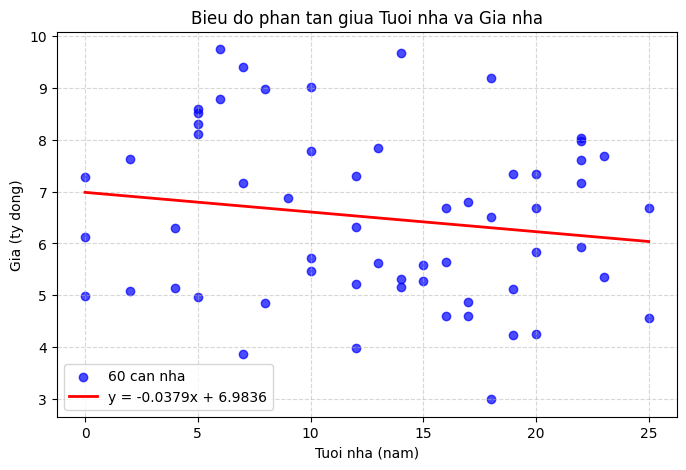

--- TRA LOI CAU HOI MO RONG ---
1. Cac diem du lieu KHONG bam sat quanh đường thăng như ở bieu do dien tich. Đam diem phan tan rat rong va tản mạn xung quanh đường hoi quy.
2. Con so w nay KHONG DANG TIN CAY CAO khi dung mot minh, vi sai so du doan se rat lon.
3. Mot he so co dau dung VOI LOGIC THUC TE (tuoi nha tang thi gia giam) LA CHUA ĐU de ket luan hai dai luong co quan he chat che. Muon ket luan quan he chat hay khong, can phai xem do phan tan (nhu R2 hoặc RMSE) xem mô hinh co giai thich tot du lieu hay khong.


In [5]:
# 7. Vẽ biểu đồ phân tán (Scatter Plot) + Đường hồi quy
plt.figure(figsize=(8, 5))
plt.scatter(df["tuoi_nha"], df["gia"], color="blue", alpha=0.7, label="60 can nha")

# Vẽ đường hồi quy tuyến tính
x_line = np.linspace(df["tuoi_nha"].min(), df["tuoi_nha"].max(), 100)
y_line = w * x_line + b
plt.plot(x_line, y_line, color="red", linewidth=2, label=f"y = {w:.4f}x + {b:.4f}")

plt.xlabel("Tuoi nha (nam)")
plt.ylabel("Gia (ty dong)")
plt.title("Bieu do phan tan giua Tuoi nha va Gia nha")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# Lưu biểu đồ thành file ảnh
plt.savefig("bai3.png", dpi=150, bbox_inches="tight")
plt.show()

# 8. Trả lời câu hỏi mở rộng
print("--- TRA LOI CAU HOI MO RONG ---")
print(
    "1. Cac diem du lieu KHONG bam sat quanh đường thăng như ở bieu do dien tich. "
    "Đam diem phan tan rat rong va tản mạn xung quanh đường hoi quy.\n"
    "2. Con so w nay KHONG DANG TIN CAY CAO khi dung mot minh, vi sai so du doan se rat lon.\n"
    "3. Mot he so co dau dung VOI LOGIC THUC TE (tuoi nha tang thi gia giam) LA CHUA ĐU "
    "de ket luan hai dai luong co quan he chat che. Muon ket luan quan he chat hay khong, "
    "can phai xem do phan tan (nhu R2 hoặc RMSE) xem mô hinh co giai thich tot du lieu hay khong."
)

**Bài tập 4: Thêm số phòng vào mô hình**

In [6]:
# -*- coding: utf-8 -*-
"""Bài tập 4: Thêm số phòng vào mô hình dự đoán giá nhà."""

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# 1. Đọc tệp dữ liệu CSV
df = pd.read_csv("gia_nha.csv")

# 2. Chuẩn bị đặc trưng X (2 cột) và biến mục tiêu y
X = df[["dien_tich", "so_phong"]]
y = df["gia"]

# 3. Chia tập học và tập kiểm tra (bắt buộc giữ random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Khởi tạo và huấn luyện mô hình
mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

# 5. Dự đoán trên tập kiểm tra và tính R2
y_pred = mo_hinh.predict(X_test)
r2_2_bien = r2_score(y_test, y_pred)

# 6. In kết quả và so sánh
print("--- KET QUA BAI TAP 4 ---")
print(f"R2 tren tap kiem tra (2 bien: dien_tich, so_phong) : {r2_2_bien:.4f}")
print("R2 o Muc 6 (1 bien: dien_tich)                        : 0.9622")
print()

# 7. Nhận xét đánh giá
print("--- SO SANH VA NHAN XET ---")
print(
    f"Nhan xet: Chi so R2 tang nhe tu 0.9622 len {r2_2_bien:.4f}.\n"
    "Danh gia: Việc them cot 'so_phong' giup mo hinh tot hon mot chut, "
    "tuy nhien muc tang la khong nhieu. Ly do la dien tich da mang phan lon "
    "thong tin quyet dinh gia nha, va so phong thuong dong bien chat che voi dien tich."
)

--- KET QUA BAI TAP 4 ---
R2 tren tap kiem tra (2 bien: dien_tich, so_phong) : 0.9698
R2 o Muc 6 (1 bien: dien_tich)                        : 0.9622

--- SO SANH VA NHAN XET ---
Nhan xet: Chi so R2 tang nhe tu 0.9622 len 0.9698.
Danh gia: Việc them cot 'so_phong' giup mo hinh tot hon mot chut, tuy nhien muc tang la khong nhieu. Ly do la dien tich da mang phan lon thong tin quyet dinh gia nha, va so phong thuong dong bien chat che voi dien tich.


**Bài tập 5: Thử hai tốc độ học khác**

In [7]:
# -*- coding: utf-8 -*-
"""Bài tập 5: Thử hai tốc độ học khác nhau trong Gradient Descent."""

import numpy as np
import pandas as pd

# 1. Đọc dữ liệu và chuẩn hóa diện tích
df = pd.read_csv("gia_nha.csv")
x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech
n = len(x)

def chay_gradient_descent(lr, so_vong=200):
    """Hàm chạy Gradient Descent với tốc độ học lr được truyền vào."""
    w, b = 0.0, 0.0
    for vong in range(1, so_vong + 1):
        y_du_doan = w * x + b
        chenh_lech = y_du_doan - y

        grad_w = (2 / n) * (chenh_lech * x).sum()
        grad_b = (2 / n) * chenh_lech.sum()

        w -= lr * grad_w
        b -= lr * grad_b

    mse_cuoi = (((w * x + b) - y) ** 2).mean()
    return mse_cuoi

# 2. Chạy thử nghiệm với 2 tốc độ học
mse_001 = chay_gradient_descent(lr=0.001)
mse_102 = chay_gradient_descent(lr=1.02)

# 3. In kết quả
print("--- KET QUA BAI TAP 5 ---")
print(f"MSE o vong 200 voi toc do hoc lr = 0.001 : {mse_001:.4f}")
print(f"MSE o vong 200 voi toc do hoc lr = 1.02  : {mse_102:.4e}")
print()

# 4. Giải thích
print("--- GIAI THICH NGUYEN NHAN ---")
print(
    "1. Voi lr = 0.001: Toc do hoc qua nho (buoc di qua ngan). Sau 200 vong, "
    "thuat toan van chua kip bo toi day cua ham sai so, do do MSE van con rat cao (chuayeu chua hoan thanh).\n"
    "2. Voi lr = 1.02: Toc do hoc qua lon (buoc di qua dai). Thuat toan nhay vọt "
    "qua day sang suon ben kia va ngay cang xa day hon, lam sai so phinh to theo cap so nhan (bi phan ky/vơ mô hinh)."
)

--- KET QUA BAI TAP 5 ---
MSE o vong 200 voi toc do hoc lr = 0.001 : 20.2175
MSE o vong 200 voi toc do hoc lr = 1.02  : 2.9039e+08

--- GIAI THICH NGUYEN NHAN ---
1. Voi lr = 0.001: Toc do hoc qua nho (buoc di qua ngan). Sau 200 vong, thuat toan van chua kip bo toi day cua ham sai so, do do MSE van con rat cao (chuayeu chua hoan thanh).
2. Voi lr = 1.02: Toc do hoc qua lon (buoc di qua dai). Thuat toan nhay vọt qua day sang suon ben kia va ngay cang xa day hon, lam sai so phinh to theo cap so nhan (bi phan ky/vơ mô hinh).


**Bài tập 6: Viết hàm dự đoán có cảnh báo**

In [8]:
# -*- coding: utf-8 -*-
"""Bài tập 6: Viết hàm dự đoán giá nhà có cảnh báo ngoại suy."""

# Hai hệ số tối ưu đã tính từ Mục 5
W_TOI_UU = 0.078367
B_TOI_UU = 0.401752


def du_doan_gia(dien_tich):
    """Hàm dự đoán giá nhà dựa trên diện tích.
    In cảnh báo nếu diện tích nằm ngoài khoảng dữ liệu thực tế [35.5, 117.5].
    """
    # Kiểm tra điều kiện ngoại suy (ngoài khoảng 35.5 đến 117.5 m2)
    if dien_tich < 35.5 or dien_tich > 117.5:
        print(
            f"  [CANH BAO] Dien tich {dien_tich} m2 nam ngoai khoang du lieu hoc (35.5 - 117.5 m2). "
            "Ket qua du doan co the khong con dang tin tin cậy!"
        )
    # Tính giá dự đoán theo công thức: y = w * x + b
    gia_du_doan = W_TOI_UU * dien_tich + B_TOI_UU
    return gia_du_doan


# --- THỬ NGHIỆM HÀM VỚI 3 GIÁ TRỊ ---
print("--- KET QUA BAI TAP 6 ---")

cac_muc_dien_tich = [60, 80, 200]

for dt in cac_muc_dien_tich:
    gia = du_doan_gia(dt)
    print(f"Can ho {dt:3d} m2 -> Gia du doan: {gia:.3f} ty dong\n")

--- KET QUA BAI TAP 6 ---
Can ho  60 m2 -> Gia du doan: 5.104 ty dong

Can ho  80 m2 -> Gia du doan: 6.671 ty dong

  [CANH BAO] Dien tich 200 m2 nam ngoai khoang du lieu hoc (35.5 - 117.5 m2). Ket qua du doan co the khong con dang tin tin cậy!
Can ho 200 m2 -> Gia du doan: 16.075 ty dong

